In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys


os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"


try:

    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"

    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")


sys.path.append("..") 

import models
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

models.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
import scanpy as sc
import pandas as pd
import os


data_dir_mob = '/home/pxy/home/pxy/data/Mouse_Olfactory_Bulb/'

n_clusters_mob = 7 

print(f"开始加载 Mouse Olfactory Bulb (MOB) 数据集...")


adata = sc.read_h5ad(os.path.join(data_dir_mob, "filtered_feature_bc_matrix.h5ad"))
adata.var_names_make_unique()


meta = pd.read_csv(os.path.join(data_dir_mob, "metadata.tsv"), sep="\t", index_col=0)


if not adata.obs_names[0] in meta.index:
    print("检测到索引不匹配，尝试进行自动对齐...")
    if "-" in adata.obs_names[0] and "-" not in str(meta.index[0]):
        meta.index = [str(i) + "-1" for i in meta.index]


adata.obs["Region"] = meta.loc[adata.obs_names, "ground_truth"]


print(f"\n数据集: Mouse Olfactory Bulb (MOB)")
print(f"Spot 总数: {adata.n_obs}")
print(f"有效标注类别数: {adata.obs['Region'].nunique()}")
print(f"空值 (NA) 数量: {adata.obs['Region'].isna().sum()}")


print("\n标注分布详情:")
print(adata.obs["Region"].value_counts())

开始加载 Mouse Olfactory Bulb (MOB) 数据集...

数据集: Mouse Olfactory Bulb (MOB)
Spot 总数: 19109
有效标注类别数: 1
空值 (NA) 数量: 0

标注分布详情:
Region
1    19109
Name: count, dtype: int64


In [3]:
adata = models.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = models.prepare_graph(adata, "spatial",n_neighbors=15)
g_expr = models.prepare_graph(adata, "expr", metric="euclidean",n_neighbors=4)
graph_dict = {"spatial": g_spatia, "expr":g_expr}

Preprocessing data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 表达特征
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [4]:
model = models.model_TwoStage(
    adata.obsm["X_pca"], 
    graph_dict, 
    n_clusters=n_clusters_mob,
    dim_input=200,
    pretrain_epochs=100,   # 预训练100轮
    finetune_epochs=100,   # 训练100轮
    gamma=0.1,             # 重构损失权重
    kappa=1.5,             # 对比损失权重
    theta=0.6,             # 平滑项损失权重
    dim_hidden=32,
    freeze_encoder=False,   # 不冻结预训练编码器
    graph_corr=0.2,
    dropout=0.2,
    gate_bias=3.0,
    residual_weight=0.2
)

In [5]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  24%|██▍       | 24/100 [00:01<00:02, 26.32it/s]

  Pretrain Epoch 10: Rec Loss = 5.874505
  Pretrain Epoch 20: Rec Loss = 5.792672
  Pretrain Epoch 30: Rec Loss = 5.696408


Pretrain:  60%|██████    | 60/100 [00:01<00:00, 67.17it/s]

  Pretrain Epoch 40: Rec Loss = 5.645453
  Pretrain Epoch 50: Rec Loss = 5.619442
  Pretrain Epoch 60: Rec Loss = 5.607845


...

  Train Epoch 80: Loss = 15.361773,Rec Loss = 5.872171, Contrast Loss = 9.818195, Smooth Loss = 0.078770


Finetune:  90%|█████████ | 90/100 [01:05<00:07,  1.35it/s]

  Train Epoch 90: Loss = 15.349496,Rec Loss = 5.872454, Contrast Loss = 9.812562, Smooth Loss = 0.072346


Finetune: 100%|██████████| 100/100 [01:12<00:00,  1.37it/s]

  Train Epoch 100: Loss = 15.338840,Rec Loss = 5.872777, Contrast Loss = 9.806852, Smooth Loss = 0.068808

  Finetune Epoch 100:
    Total Loss   = 15.3388
    Rec Loss     = 5.8728
    Contrast Loss = 9.8069
    Smooth Loss = 0.0688

✓ Finetune finished (max epochs reached)


In [6]:
# ========== 聚类 ==========
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters_mob, key="model_twostage", refinement=True,cluster_methods='mclust')


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 19109 × 27092
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Region', 'n_counts', 'mclust', 'mclust_refined'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std'
    uns: 'log1p'
    obsm: 'spatial', 'X_pca', 'model_twostage'
    layers: 'count'

In [7]:
import matplotlib.pyplot as plt
import scanpy as sc

figures_dir = "../figures_MOB_use_raw_2"

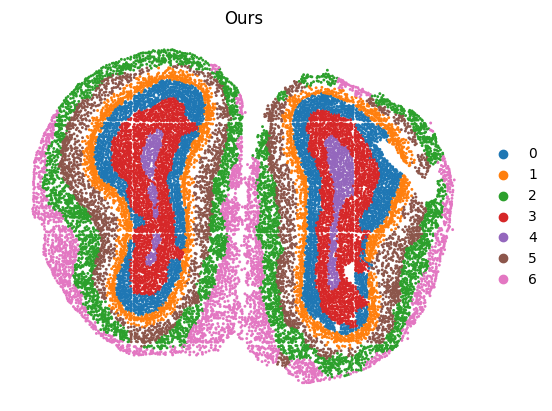

In [8]:
adata.obs["model"] = adata.obs["mclust_refined"]

ax = sc.pl.spatial(
    adata, 
    color=["model"], 
    spot_size=40,      
    frameon=False, 
    show=False, 
    title=[f"Ours"]
)


if isinstance(ax, list):
    ax[0].invert_yaxis()
else:
    ax.invert_yaxis()


plt.savefig(f"{figures_dir}/MOB_spatial.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

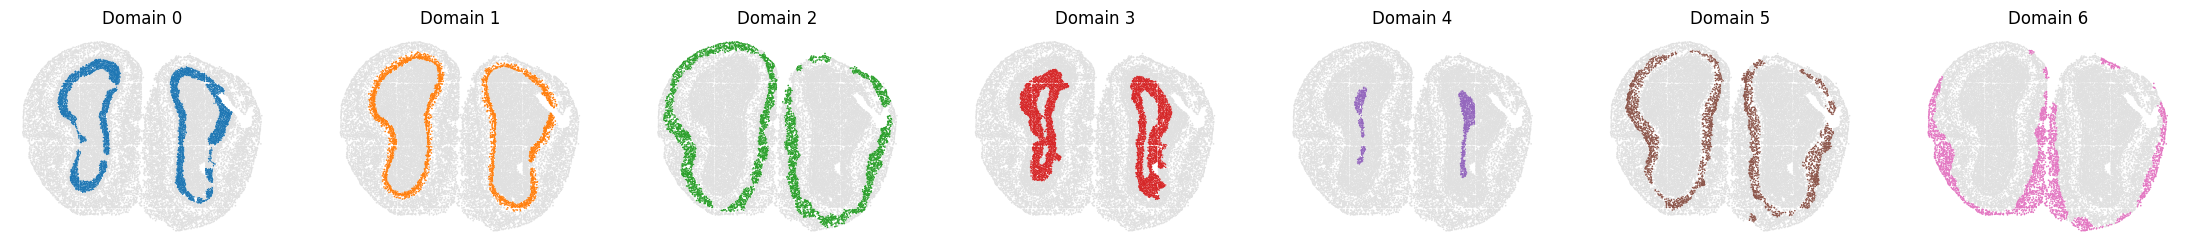

In [9]:

n_cluster = adata.obs["model"].nunique()

pl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']


fig, axes = plt.subplots(nrows=1, ncols=n_cluster, figsize=(4 * n_cluster, 4))


clusters = sorted(adata.obs["model"].unique())

for i, cluster in enumerate(clusters):

    adata.obs[f"temp_{cluster}"] = (adata.obs["model"] == cluster).astype(str)
    

    ax_sub = sc.pl.spatial(
        adata, color=f"temp_{cluster}", 
        spot_size=40, frameon=False, show=False, 
        palette=['#e0e0e0', pl[i]], # 灰色 + 彩色
        ax=axes[i], legend_loc=None, title=f"Domain {cluster}"
    )
    ax_sub[0].invert_yaxis()
    
plt.savefig(f"{figures_dir}/MOB_SingleDomains.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [10]:
print(adata.obs["model"].value_counts())

model
3    3843
2    3677
0    3378
6    2505
5    2495
1    2456
4     755
Name: count, dtype: int64


Domain 6 matches: 2505 spots
Domain 2 matches: 3677 spots
Domain 5 matches: 2495 spots
Domain 1 matches: 2456 spots
Domain 0 matches: 3378 spots
Domain 3 matches: 3843 spots
Domain 4 matches: 755 spots


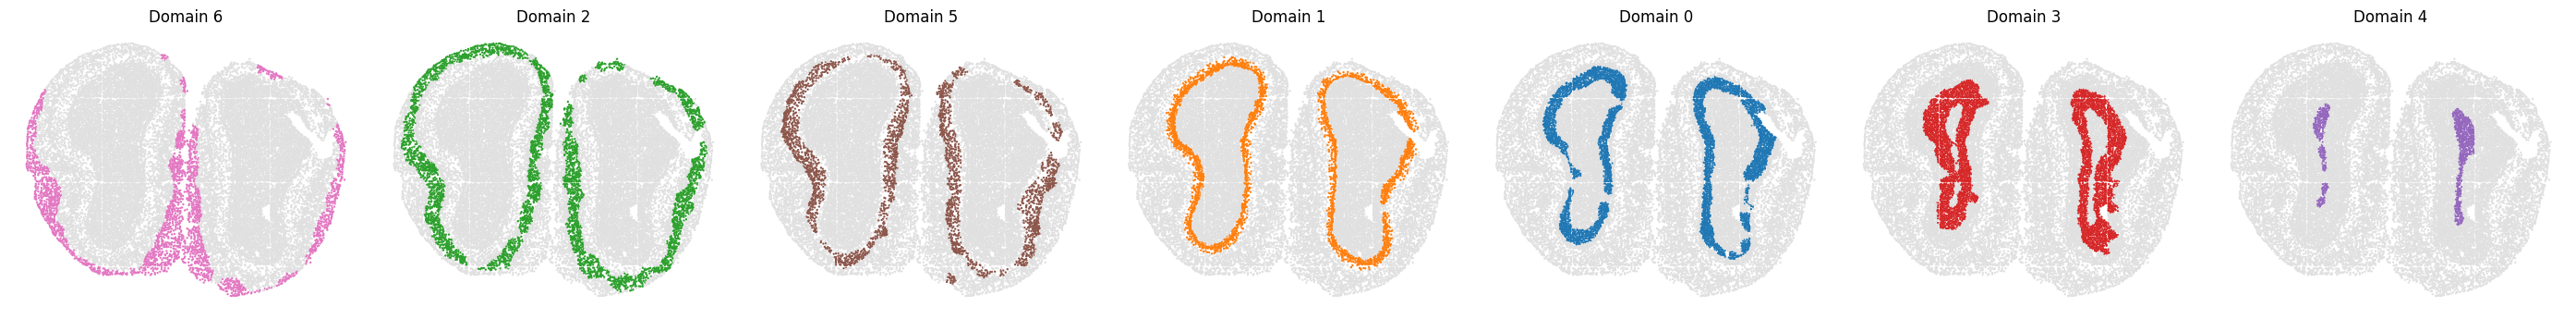

In [11]:
adata.obs["model"] = adata.obs["model"].astype(str)
target_order = [str(x) for x in [6, 2, 5, 1, 0, 3, 4]] 

pl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

all_clusters_sorted = sorted(target_order, key=lambda x: int(x))
color_map = {cluster: pl[i] for i, cluster in enumerate(all_clusters_sorted)}

fig, axes = plt.subplots(nrows=1, ncols=len(target_order), figsize=(4 * len(target_order), 4))

for i, cluster in enumerate(target_order):
    mask_name = f"plot_domain_{cluster}"
    
    is_target = (adata.obs["model"] == cluster)
    print(f"Domain {cluster} matches: {is_target.sum()} spots") 
    
    adata.obs[mask_name] = is_target.map({True: 'Target', False: 'Other'}).astype('category')
    
    sc.pl.spatial(
        adata, 
        color=mask_name, 
        spot_size=40,
        frameon=False, 
        show=False, 
        palette={'Other': '#e0e0e0', 'Target': color_map[cluster]}, 
        ax=axes[i], 
        legend_loc=None, 
        title=f"Domain {cluster}",
        library_id=None 
    )
    
    ax = axes[i]
    ax.invert_yaxis() 
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(f"{figures_dir}/MOB_SingleDomains_ordered.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

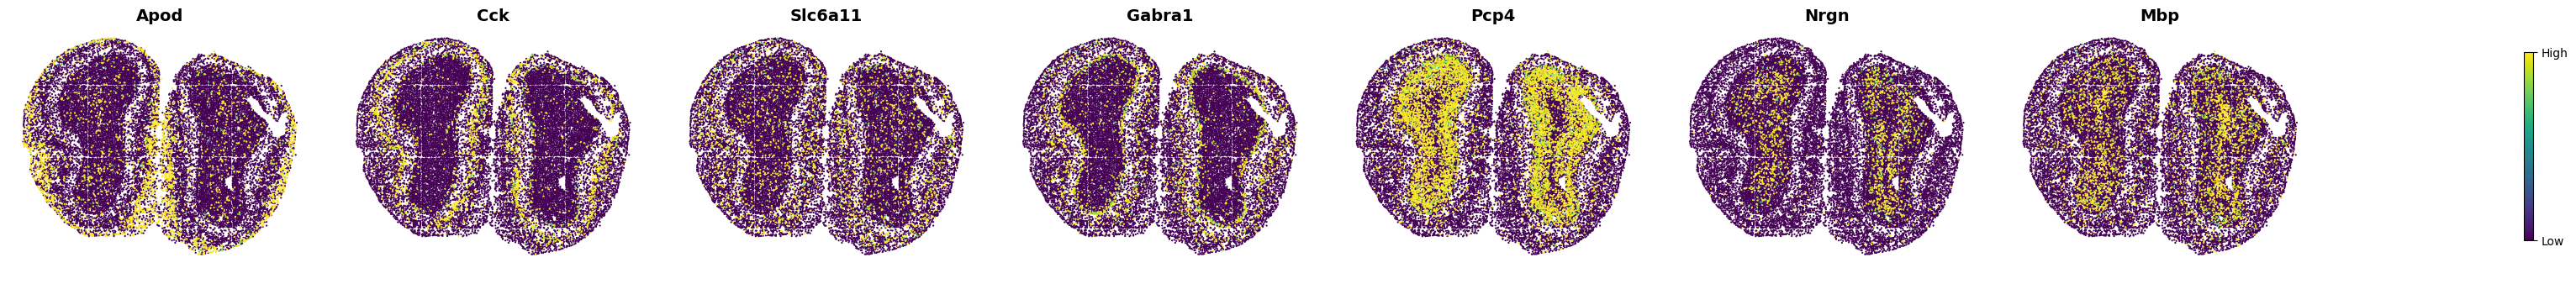

In [12]:
available_markers = ['Apod', 'Cck', 'Slc6a11', 'Gabra1', 'Pcp4', 'Nrgn', 'Mbp']

n_plots = len(available_markers)

fig, axes = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4 * (n_plots + 1), 4))

for i, gene in enumerate(available_markers):
    sc.pl.spatial(
        adata, color=gene, use_raw=True, spot_size=40,
        frameon=False, show=False, ax=axes[i],
        colorbar_loc=None, cmap='viridis', vmax='p99'
    )
    axes[i].axis('off')
    axes[i].invert_yaxis()

    axes[i].set_title(gene, fontsize=14, fontweight='bold', pad=5)
    
    scalar_mappable = axes[i].collections[0]
    scalar_mappable.set_clim(0, 3.0)


axes[-1].axis('off')
if scalar_mappable is not None:
    cbar = fig.colorbar(
        scalar_mappable, orientation='vertical', 
        shrink=0.7, 
        ax=axes[-1], fraction=0.4, pad=0
    )
    cbar.set_ticks([0, 3.0])
    cbar.set_ticklabels(['Low', 'High'])


plt.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.1, wspace=0.1)


plt.savefig(f"{figures_dir}/MOB_MarkerGenes_ordered.png", bbox_inches='tight', pad_inches=0.02, dpi=300)
plt.show()
plt.close()